In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the cleaned dataset
processed_data_path = r'A:\desktop\New folder\P\Ratul\Supply_Chain_Thesis\data\processed\cleaned_data.csv'
print("Loading cleaned dataset...")
df = pd.read_csv(processed_data_path)

print(f"Dataset Shape: {df.shape}")

Loading cleaned dataset...
Dataset Shape: (180519, 48)


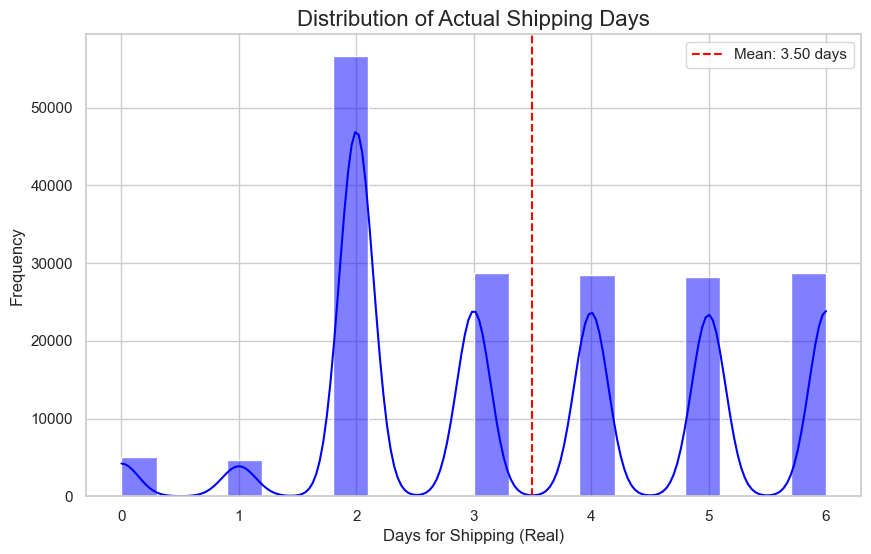

In [2]:
plt.figure(figsize=(10, 6))
sns.histplot(df['days_for_shipping_real'], bins=20, kde=True, color='blue')
plt.title('Distribution of Actual Shipping Days', fontsize=16)
plt.xlabel('Days for Shipping (Real)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.axvline(df['days_for_shipping_real'].mean(), color='red', linestyle='--', label=f"Mean: {df['days_for_shipping_real'].mean():.2f} days")
plt.legend()
plt.show()

C:\Users\manwa_vjycapl\AppData\Local\Temp\ipykernel_27204\1010024239.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='shipping_mode', y='days_for_shipping_real', data=df, palette='Set2')


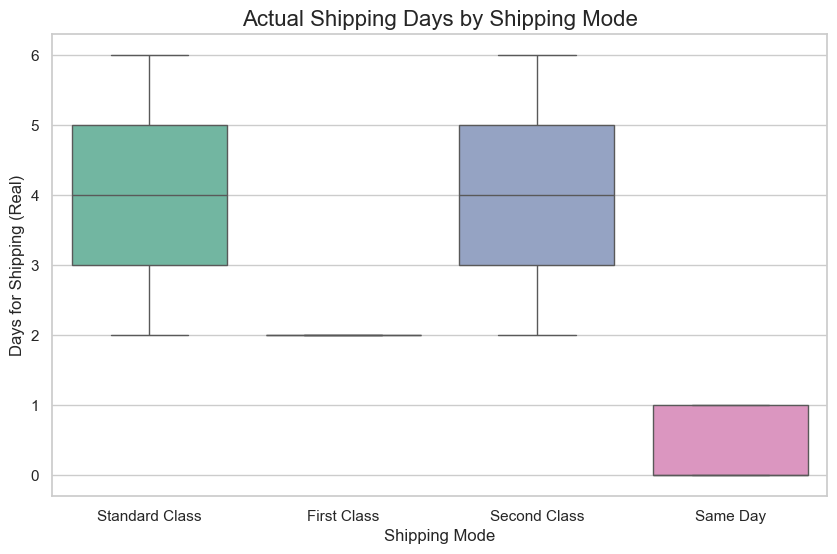

Median Shipping Days by Mode:
shipping_mode
First Class       2.0
Same Day          0.0
Second Class      4.0
Standard Class    4.0
Name: days_for_shipping_real, dtype: float64


In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='shipping_mode', y='days_for_shipping_real', data=df, palette='Set2')
plt.title('Actual Shipping Days by Shipping Mode', fontsize=16)
plt.xlabel('Shipping Mode', fontsize=12)
plt.ylabel('Days for Shipping (Real)', fontsize=12)
plt.show()

# Calculate median days per shipping mode to serve as our future Baseline Rules
print("Median Shipping Days by Mode:")
print(df.groupby('shipping_mode')['days_for_shipping_real'].median())

C:\Users\manwa_vjycapl\AppData\Local\Temp\ipykernel_27204\3985533510.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='delivery_status', data=df, palette='pastel', order=df['delivery_status'].value_counts().index)


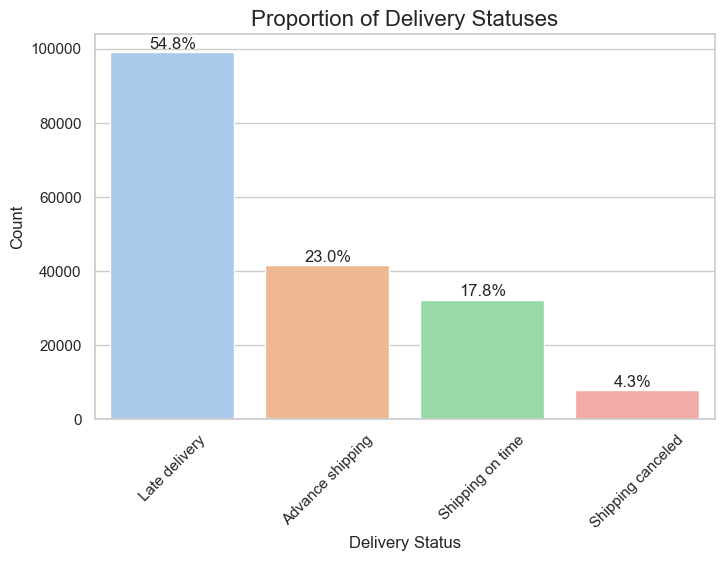

In [4]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='delivery_status', data=df, palette='pastel', order=df['delivery_status'].value_counts().index)
plt.title('Proportion of Delivery Statuses', fontsize=16)
plt.xlabel('Delivery Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.15
    y = p.get_height() + 1000
    ax.annotate(percentage, (x, y), size=12)

plt.show()

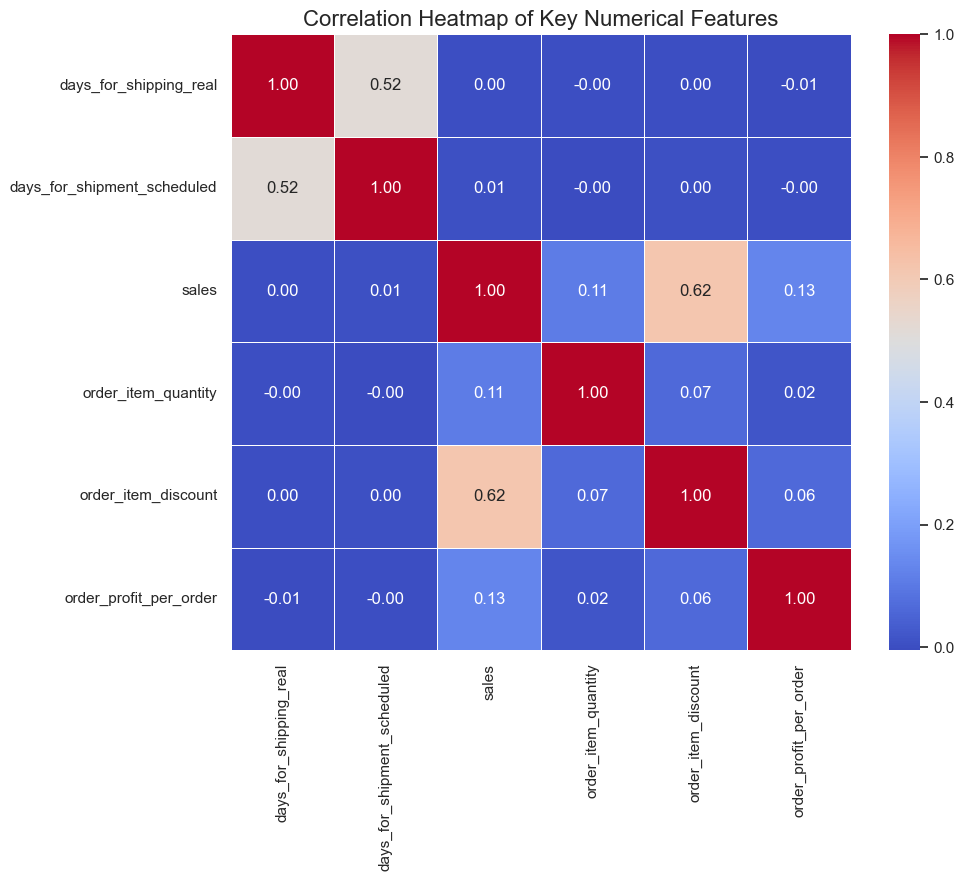

In [5]:
# Select only a subset of numerical columns for a clean heatmap
num_cols = ['days_for_shipping_real', 'days_for_shipment_scheduled', 'sales', 
            'order_item_quantity', 'order_item_discount', 'order_profit_per_order']

plt.figure(figsize=(10, 8))
corr_matrix = df[num_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Key Numerical Features', fontsize=16)
plt.show()

In [6]:
import os
import matplotlib.pyplot as plt

# Ensure the directories exist based on your project structure
os.makedirs('../reports/figures', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

# 1. Save a sample EDA plot (Distribution of Lead Times)
plt.figure(figsize=(10, 6))
sns.histplot(df['days_for_shipping_real'], bins=20, kde=True, color='blue')
plt.title('Distribution of Actual Shipping Days')
plt.xlabel('Days')
plt.ylabel('Frequency')
plt.savefig('../reports/figures/eda_shipping_days_distribution.png', bbox_inches='tight')
plt.close()

print("EDA visualizations successfully saved to reports/figures/")

EDA visualizations successfully saved to reports/figures/
